# HyPhy Omega Distribution Plots

In [ ]:
import sys
import os
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import get_silk_genes as silk

pd.set_option('display.max_columns', None, 'display.max_rows', 50)

# Ensure the src directory is in the Python path
scripts = os.path.abspath('')
src_path = os.path.abspath(os.path.join(scripts, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

from hyphy_results_parser import (
    RelaxResult,
    BustedPhResult
)
from omega_plots import (
    plot_omega_distributions,
    plot_omega_single_gene
)

# Define paths to data and results directories
data = os.path.join(scripts, "..", "data/")
figures = os.path.join(scripts, "..", "figures/")
hyphy_results = os.path.join(scripts, "..", "results/hyphy_results_cache/")

In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)

In [40]:
# Load the saved RELAX results
relax_result = RelaxResult.load_from_pickle(str(hyphy_results + "relax_results.pkl"))

# Load the saved BUSTED-PH results
busted_ph_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_results.pkl"))

# Load the saved BUSTED-PH-REV results
busted_ph_rev_result = BustedPhResult.load_from_pickle(str(hyphy_results + "busted_ph_rev_results.pkl"))

Filter out extremely large omega values from the results (arbitrary threshold of 10,000)

In [41]:
relax_result_fltrd = relax_result.filter_omega(10000)
busted_ph_result_fltrd = busted_ph_result.filter_omega(10000)
busted_ph_rev_result_fltrd = busted_ph_rev_result.filter_omega(10000)

In [42]:
relax_df_fltrd = relax_result_fltrd.results_df
busted_ph_df_fltrd = busted_ph_result_fltrd.results_df
busted_ph_rev_df_fltrd = busted_ph_rev_result_fltrd.results_df

## Omega plots

(<Figure size 600x500 with 5 Axes>, array([<Axes: >, <Axes: >], dtype=object))

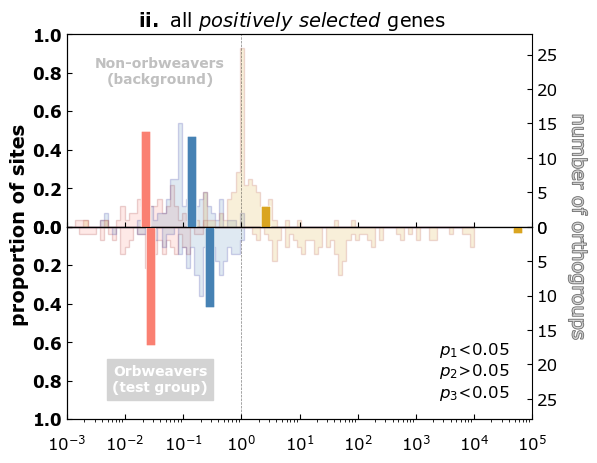

In [43]:
x=busted_ph_df_fltrd[busted_ph_df_fltrd['result']=='hit']
result='positively selected'.replace(" ", "\ ")
bottom_title = 'Orbweavers\n(test group)'
top_title = 'Non-orbweavers\n(background)'

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    filename=str(figures + 'figure_2/busted_ph_omega_dist.png'),
    transparent=False
    )

(<Figure size 600x500 with 11 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       dtype=object))

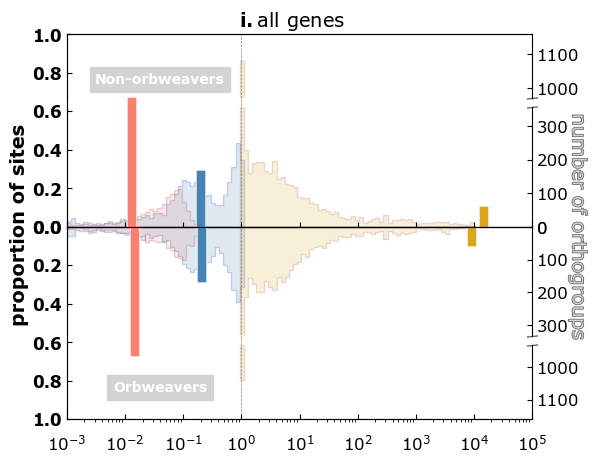

In [44]:
x=relax_df_fltrd

result='all'
top_title = 'Non-orbweavers'
bottom_title = 'Orbweavers'

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    filename=str(figures + 'figure_2/relax_all_omega_dist.png'),
    transparent=False
    )

(<Figure size 600x500 with 11 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       dtype=object))

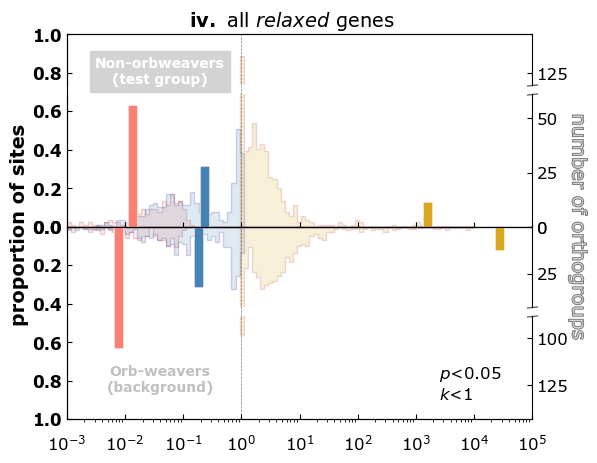

In [45]:
x=relax_df_fltrd[relax_df_fltrd['result']=='relaxed']
result='relaxed'
top_title = 'Non-orbweavers\n(test group)'
bottom_title = 'Orb-weavers\n(background)'

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    filename=str(figures + 'figure_2/relax_relaxed_omega_dist.png'),
    transparent=False
    )

(<Figure size 600x500 with 11 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       dtype=object))

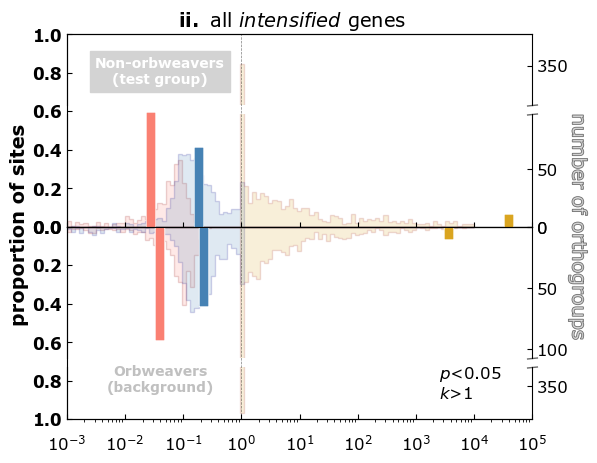

In [46]:
x=relax_df_fltrd[relax_df_fltrd['result']=='intensified']
result='intensified'
top_title = 'Non-orbweavers\n(test group)'
bottom_title = 'Orbweavers\n(background)'

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    filename=str(figures + 'figure_2/relax_intensified_omega_dist.png'),
    transparent=False
)

Plot example genes from each selection pattern

(<Figure size 550x500 with 1 Axes>, <Axes: >)

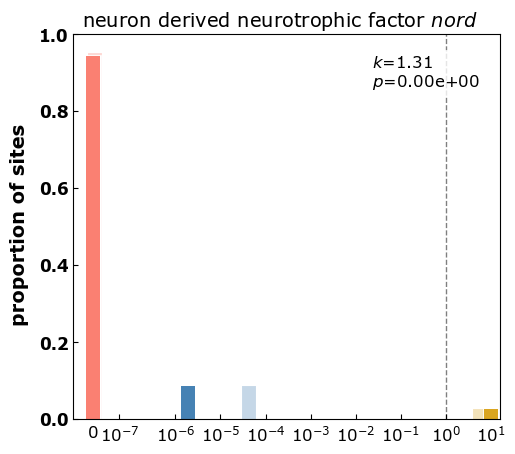

In [47]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0061683', 
    'neuron derived neurotrophic factor $\it{nord}$',  
    offset_zero=True, 
    k=True,
    filename=str(figures + 'figure_2/relax_nord_omega_plot.png'),
    transparent=False
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

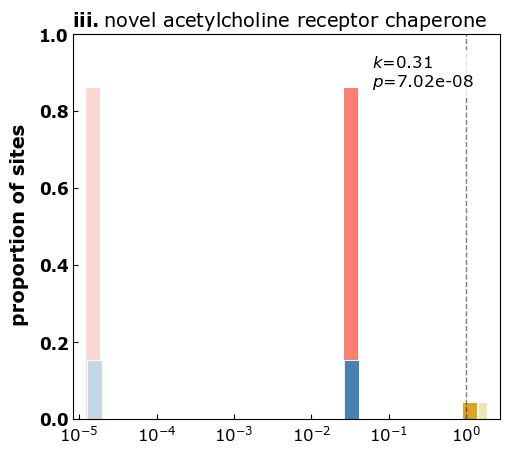

In [48]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0066983', 
    'novel acetylcholine receptor chaperone', 
    i='iii. ', 
    k=True,
    filename=str(figures + 'figure_2/relax_acetylcholine_omega_plot.png'),
    transparent=False
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

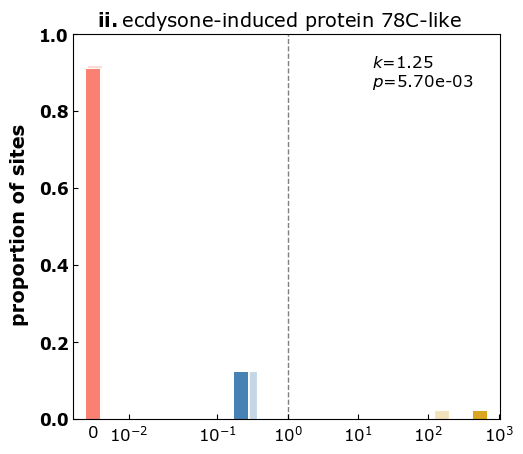

In [49]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0048857', 
    'ecdysone-induced protein 78C-like', 
    i='ii. ',  
    offset_zero=True, 
    k=True,
    filename=str(figures + 'figure_2/relax_ecdysone_omega_plot.png'),
    transparent=False
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

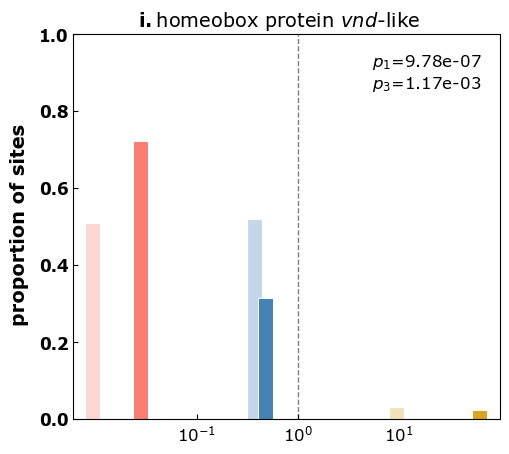

In [50]:
plot_omega_single_gene(busted_ph_df_fltrd, 
                       'N5.HOG0069577', 
                       'homeobox protein $\it{vnd}$-like', 
                       i='i. ',
                       filename=str(figures + 'figure_2/busted_ph_hox_omega_plot.png'),
                        transparent=False
                       )